**NAME** CHENCHIRA BAMRUNG
**ID** 6210550371

In [ ]:
#! pip install kaggle

In [ ]:
#Need to upload file in session storage
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
! kaggle datasets download andradaolteanu/gtzan-dataset-music-genre-classification

100% 1.21G/1.21G [00:28<00:00, 45.6MB/s]
100% 1.21G/1.21G [00:28<00:00, 45.4MB/s]


In [ ]:
! unzip gtzan-dataset-music-genre-classification

Archive:  gtzan-dataset-music-genre-classification.zip
  inflating: Data/features_30_sec.csv  
  inflating: Data/features_3_sec.csv  
  inflating: Data/genres_original/blues/blues.00000.wav  
  inflating: Data/genres_original/blues/blues.00001.wav  
  inflating: Data/genres_original/blues/blues.00002.wav  
  inflating: Data/genres_original/blues/blues.00003.wav  
  inflating: Data/genres_original/blues/blues.00004.wav  
  inflating: Data/genres_original/blues/blues.00005.wav  
  inflating: Data/genres_original/blues/blues.00006.wav  
  inflating: Data/genres_original/blues/blues.00007.wav  
  inflating: Data/genres_original/blues/blues.00008.wav  
  inflating: Data/genres_original/blues/blues.00009.wav  
  inflating: Data/genres_original/blues/blues.00010.wav  
  inflating: Data/genres_original/blues/blues.00011.wav  
  inflating: Data/genres_original/blues/blues.00012.wav  
  inflating: Data/genres_original/blues/blues.00013.wav  
  inflating: Data/genres_original/blues/blues.00014.wa

In [ ]:
#import libraly
import math
import json
import librosa
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

**PROCESS**
1. Crete a function to do the augmentation on audio file. (Pitch Change and Add noise)
2. Extract MFCC on original signal and augmented signal
3. Train-Test-Validate Split
4. Build the CNN Model
5. Train the Model
6. Evaluate model with testing set



In [ ]:
dataset_path = '/content/Data/genres_original'
SAMPLE_RATE = 22050
DURATION = 30
sample_per_song = SAMPLE_RATE*DURATION

In [ ]:
import os
from sklearn.model_selection import train_test_split

# List all audio file paths
audio_files = []
genre = []

for dirpath, dirnames, filenames in os.walk(dataset_path):
    for filename in filenames:
        if filename.endswith(".wav"):
          #print("filename", filename)
          audio_files.append(os.path.join(dirpath, filename))
            #We are in subfolder now

    if dirpath is not dataset_path:
      pathname_split = dirpath.split("/")  #pathname => /content/Data/genres_original/reggae, gonna split it
      genre_name = pathname_split[-1]
      genre.append(genre_name)
      print(genre_name)

pop
hiphop
disco
country
blues
jazz
reggae
classical
metal
rock


In [ ]:
#Train Test Split the file
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(audio_files, test_size=0.2)
train_set, validation_set = train_test_split(train_set, test_size=0.2)

In [ ]:
len(train_set)

640

In [ ]:
len(validation_set)

160

In [ ]:
len(test_set)

200

In [ ]:
def augment_signal(sample, sr):

  # 2 pitch
  for n_steps in [4,6]:
    signal_pitch = librosa.effects.pitch_shift(y=sample, sr=SAMPLE_RATE, n_steps=5)

  wn = np.random.randn(len(sample))
  signal_noise = sample + 0.005*wn

  return signal_pitch, signal_noise,

In [ ]:
def training_mfccs(dataset_path, n_mfcc, n_fft, hop_length, num_segments):

    data_dict = {
        "mfcc": [],
        "labels": [],
    }

    sample_per_seg = int(sample_per_song/num_segments)
    expected_mfcc = math.ceil(sample_per_seg/hop_length)

    for file_path in dataset_path:
      #print(file_path)
      if file_path == '/content/Data/genres_original/jazz/jazz.00054.wav':
        print('skip this file due to some problem i cannot fix')
        pass
      else:
        signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
        #Pass to Augment
        signal_pitch, signal_noise = augment_signal(signal, sr)

        for s in range(num_segments):
          start_sample = sample_per_seg*s
          finish_sample = start_sample + sample_per_seg
          mfcc_sl = librosa.feature.mfcc(y=signal[start_sample:finish_sample], sr=SAMPLE_RATE, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
          mfcc_sl = mfcc_sl.T
          mfcc_pitch = librosa.feature.mfcc(y=signal_pitch[start_sample:finish_sample], sr=SAMPLE_RATE, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
          mfcc_pitch = mfcc_pitch.T
          mfcc_noise = librosa.feature.mfcc(y=signal_noise[start_sample:finish_sample], sr=SAMPLE_RATE, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
          mfcc_noise = mfcc_noise.T

          if len(mfcc_sl) == expected_mfcc:
            data_dict["mfcc"].append(mfcc_sl.tolist())
          if len(mfcc_pitch) == expected_mfcc:
            data_dict["mfcc"].append(mfcc_pitch.tolist())
          if len(mfcc_noise) == expected_mfcc:
            data_dict["mfcc"].append(mfcc_noise.tolist())

            for u in range(len(genre)):
              split =  file_path.split("/")
              #print(split)
              if split[4] == genre[u]:
                for z in range(0,3):
                  data_dict["labels"].append(int(u))

    return data_dict


In [ ]:
def testing_mfccs(dataset_path, n_mfcc, n_fft, hop_length, num_segments):

    data_dict = {
        "mfcc": [],
        "labels": [],
    }

    sample_per_seg = int(sample_per_song/num_segments)
    expected_mfcc = math.ceil(sample_per_seg/hop_length)

    for file_path in dataset_path:
      #print(file_path)
      if file_path == '/content/Data/genres_original/jazz/jazz.00054.wav':
        print('skip this file due to some problem i cannot fix')
      else:
        signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)

        for s in range(num_segments):
          start_sample = sample_per_seg*s
          finish_sample = start_sample + sample_per_seg
          mfcc_sl = librosa.feature.mfcc(y=signal[start_sample:finish_sample], sr=SAMPLE_RATE, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
          mfcc_sl = mfcc_sl.T

          if len(mfcc_sl) == expected_mfcc:
            data_dict["mfcc"].append(mfcc_sl.tolist())

            for u in range(len(genre)):
              split =  file_path.split("/")
              #print(split)
              if split[4] == genre[u]:
                data_dict["labels"].append(int(u))

    return data_dict


In [ ]:
#data_dict, data_array = extract_mfccs(dataset_path, n_mfcc=13, n_fft=2048, hop_length=512, num_segments=3)
x_train_dict = training_mfccs(train_set, n_mfcc=13, n_fft=2048, hop_length=512, num_segments=10)
x_valid_dict = testing_mfccs(validation_set, n_mfcc=13, n_fft=2048, hop_length=512, num_segments=10)
x_test_dict = testing_mfccs(test_set, n_mfcc=13, n_fft=2048, hop_length=512, num_segments=10)

skip this file due to some problem i cannot fix


In [ ]:
#Declare Input and Label to NN
#mfcc_inputs = np.array(x_train_dict["mfcc"])
#targets = np.array(x_train_dict["labels"])

x_train = np.array(x_train_dict["mfcc"])
y_train = np.array(x_train_dict["labels"])
x_validation = np.array(x_valid_dict["mfcc"])
y_validation = np.array(x_valid_dict["labels"])
x_test = np.array(x_test_dict["mfcc"])
y_test = np.array(x_test_dict["labels"])

#Declare Input Shape
input_shape = (x_train.shape[1], x_train.shape[2])

In [ ]:
x_train.shape

(19161, 130, 13)

In [ ]:
input_shape

(130, 13)

**MODEL IMPLEMENTATION**
After built the model, train it with training set and evaluate with validation set. Tuning model and retrain until got the satisfy result

In [ ]:
from tensorflow import keras
from keras.layers import Activation, Dense, Flatten, Dropout
from keras.models import Sequential
from keras import regularizers
from keras import layers
#from keras import models
#from keras.regularizers import l2


def LSTM_model(input_shape):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.LSTM(64, input_shape=input_shape, return_sequences=True))
    model.add(layers.BatchNormalization())
    model.add(Dropout(0.2))
    model.add(tf.keras.layers.LSTM(32))
    model.add(layers.BatchNormalization())
    model.add(Dropout(0.2))
    model.add(tf.keras.layers.Dense(16, activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(Dropout(0.4))
    model.add(tf.keras.layers.Dense(10, activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(Dropout(0.4))
    model.add(tf.keras.layers.Dense(10,activation = "softmax"))

    # compile model
    model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001), loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

In [ ]:
LSTM_model = LSTM_model(input_shape)
LSTM_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 130, 64)           19968     
                                                                 
 batch_normalization (BatchN  (None, 130, 64)          256       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 130, 64)           0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 batch_normalization_1 (Batc  (None, 32)               128       
 hNormalization)                                                 
                                                                 
 dropout_1 (Dropout)         (None, 32)                0

In [ ]:
#Train the model
trained_LSTM = LSTM_model.fit(x_train, y_train, validation_data = (x_validation, y_validation), epochs = 40, batch_size = 32, verbose = 2)

Epoch 1/40
599/599 - 99s - loss: 2.3597 - accuracy: 0.1684 - val_loss: 1.9135 - val_accuracy: 0.3700 - 99s/epoch - 165ms/step
Epoch 2/40
599/599 - 91s - loss: 2.0416 - accuracy: 0.2480 - val_loss: 1.7571 - val_accuracy: 0.4044 - 91s/epoch - 152ms/step
Epoch 3/40
599/599 - 93s - loss: 1.9150 - accuracy: 0.3003 - val_loss: 1.6985 - val_accuracy: 0.4156 - 93s/epoch - 155ms/step
Epoch 4/40
599/599 - 91s - loss: 1.8543 - accuracy: 0.3168 - val_loss: 1.6416 - val_accuracy: 0.3875 - 91s/epoch - 151ms/step
Epoch 5/40
599/599 - 90s - loss: 1.8024 - accuracy: 0.3313 - val_loss: 1.5527 - val_accuracy: 0.4288 - 90s/epoch - 151ms/step
Epoch 6/40
599/599 - 89s - loss: 1.7489 - accuracy: 0.3596 - val_loss: 1.5533 - val_accuracy: 0.4313 - 89s/epoch - 149ms/step
Epoch 7/40
599/599 - 90s - loss: 1.7198 - accuracy: 0.3681 - val_loss: 1.5407 - val_accuracy: 0.4219 - 90s/epoch - 150ms/step
Epoch 8/40
599/599 - 89s - loss: 1.6888 - accuracy: 0.3786 - val_loss: 1.4671 - val_accuracy: 0.4694 - 89s/epoch - 148

In [ ]:
#Evaluate
test_err, test_acc = LSTM_model.evaluate(x_test, y_test, verbose = 2)
print("Accuracy on testing set is", test_acc)

63/63 - 3s - loss: 1.1395 - accuracy: 0.6498 - 3s/epoch - 51ms/step
Accuracy on testing set is 0.6498249173164368


<Figure size 640x480 with 0 Axes>

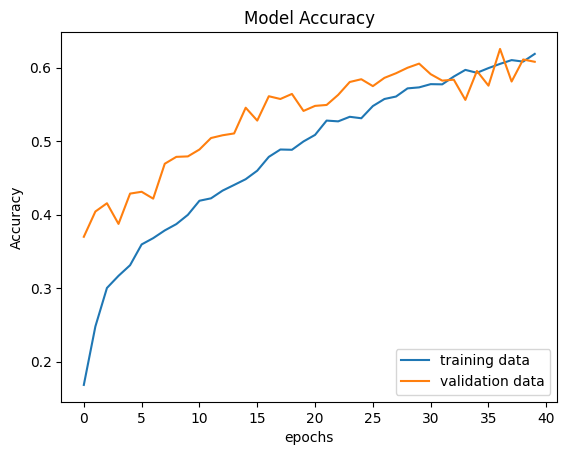

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

plt.plot(trained_LSTM.history['accuracy'])
plt.plot(trained_LSTM.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('epochs')
plt.legend(['training data', 'validation data'], loc = 'lower right')
plt.figure()
#plt.show()

<Figure size 640x480 with 0 Axes>

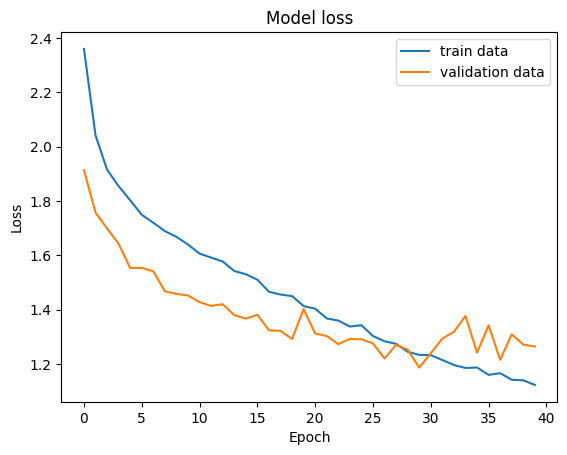

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.plot(trained_LSTM.history['loss'])
plt.plot(trained_LSTM.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train data', 'validation data'], loc='upper right')
#plt.legend()

plt.figure()